In [1]:
%matplotlib inline

In [2]:
# General imports
import matplotlib.pyplot as plt
import numpy as np

# Unnecessary--just a hack to unload PyNitride (if already imported) before (re-)importing
# otherwise I have to restart the kernel to absorb changes every time I change PyNitride code
import sys; [sys.modules.pop(k) for k in list(sys.modules) if 'pynitride' in k]

# PyNitride
from pynitride.examples.pchannel_GaN_AlN_HFET.pFET_example import define_mesh
from pynitride.examples.pchannel_GaN_AlN_HFET.pFET_visualization import valence_band_panels
from pynitride.physics.material import AlGaN
from pynitride import Mesh, MaterialBlock, UniformLayer
from pynitride import to_unit, nm, eV, cm, meV
from pynitride import RMesh2D_Polar, RMesh1D
from pynitride import Simulation
from pynitride import log

In [3]:
# OPTION A: Using an even spaced temperature interval
if False:
    t_start=300; t_stop=300; t_stop=10; t_step=10;
    num_t=int(np.round(np.abs((t_stop-t_start)/t_step)))+1
    assert np.isclose(np.abs(t_step)*(num_t-1),np.abs(t_stop-t_start)), "Make sure to provide an even-spaced step"
    t_points=np.linspace(t_start,t_stop,num_t,endpoint=True)

# OPTION B: Using an explicit list of temperatures
if True:
    t_points=[300,200,150,100,50,10]

In [4]:
sim=Simulation(f'pFET_nonInGaN_Tsweep',define_mesh=define_mesh,
           solve_flow=Simulation.flow_semiclassicalramp_mbkp,
           solve_opts ={'T':t_points[0],'ramp_T':t_points,'mbkp_opts':{'num_eigenvalues':6},'Va':4,
                        'mbkp_loop_opts':{'init_activation':.1, 'inc_activation':1.3},
                        'Tramp_loop_opts':{'init_activation':.5,'inc_activation':1.3,'min_activation':.005}})

# Warning, this only checks for the final save file, and if it is found, the sim will be loaded instead of run.
# So if you, eg, change the intermediate temperatures, this won't know to re-run
# and also, the files from old temperatures from previous runs would still be sitting around
# In short, if you use force=False, you are responsible for cleaning up debris and knowing when something has changed.
sim.load(force=False)

2023-12-10 21:36:16.943262     Mesh points 580
2023-12-10 21:36:16.945276     Hoping to load previous run from pFET_nonInGaN_Tsweep*
2023-12-10 21:36:16.952272     Loaded


In [5]:
mesh_opts_withcap={'cap_t':15*nm,'cap_y':.05,'cap_Na':4e19/cm**3}
sim=Simulation(f'pFET_yesInGaN_Tsweep',define_mesh=define_mesh,
           mesh_opts=mesh_opts_withcap,
           solve_flow=Simulation.flow_semiclassicalramp_mbkp,
           solve_opts ={'T':t_points[0],'ramp_T':t_points,'mbkp_opts':{'num_eigenvalues':6},'Va':4,
                        'mbkp_loop_opts':{'init_activation':.1, 'inc_activation':1.3},
                        'Tramp_loop_opts':{'init_activation':.5,'inc_activation':1.3,'min_activation':.005}})

# Warning, this only checks for the final save file, and if it is found, the sim will be loaded instead of run.
# So if you, eg, change the intermediate temperatures, this won't know to re-run
# and also, the files from old temperatures from previous runs would still be sitting around
# In short, if you use force=False, you are responsible for cleaning up debris and knowing when something has changed.
sim.load(force=False)

2023-12-10 21:36:17.015234     Mesh points 1053
2023-12-10 21:36:17.019232     Hoping to load previous run from pFET_yesInGaN_Tsweep*
2023-12-10 21:36:17.037128     Loaded


2023-12-10 21:36:17.624433     Mesh points 580
2023-12-10 21:36:17.628511     Hoping to load previous run from pFET_nonInGaN_Tsweep_300*
2023-12-10 21:36:17.638503     Loaded
Temperature 300K
Holes: 2.94 x10^13/cm^2
EV-EF [meV]: 406.36 meV
2023-12-10 21:36:19.267563     Mesh points 580
2023-12-10 21:36:19.268563     Hoping to load previous run from pFET_nonInGaN_Tsweep_200*
2023-12-10 21:36:19.275567     Loaded
Temperature 200K
Holes: 2.92 x10^13/cm^2
EV-EF [meV]: 412.93 meV
2023-12-10 21:36:20.926707     Mesh points 580
2023-12-10 21:36:20.928717     Hoping to load previous run from pFET_nonInGaN_Tsweep_150*
2023-12-10 21:36:20.937713     Loaded
Temperature 150K
Holes: 2.92 x10^13/cm^2
EV-EF [meV]: 415.22 meV
2023-12-10 21:36:22.555239     Mesh points 580
2023-12-10 21:36:22.557236     Hoping to load previous run from pFET_nonInGaN_Tsweep_100*
2023-12-10 21:36:22.564765     Loaded
Temperature 100K
Holes: 2.91 x10^13/cm^2
EV-EF [meV]: 416.60 meV
2023-12-10 21:36:24.170142     Mesh poin

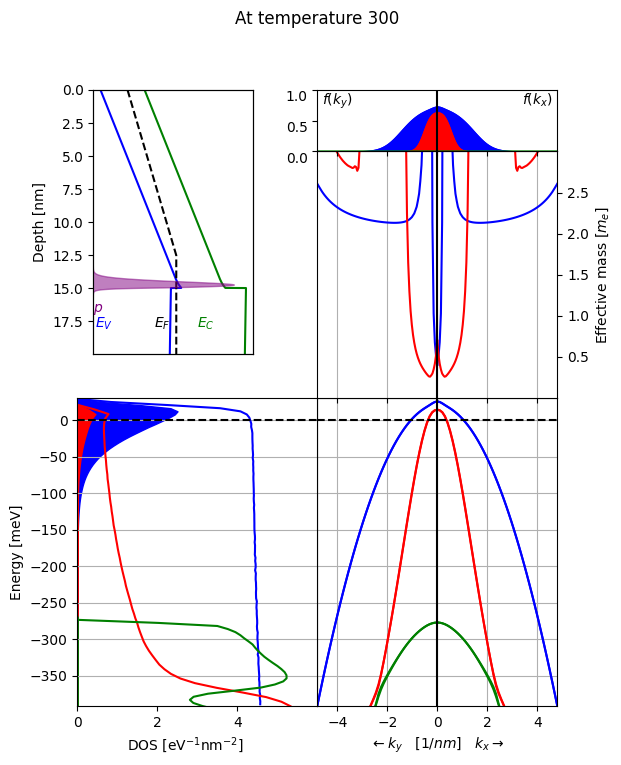

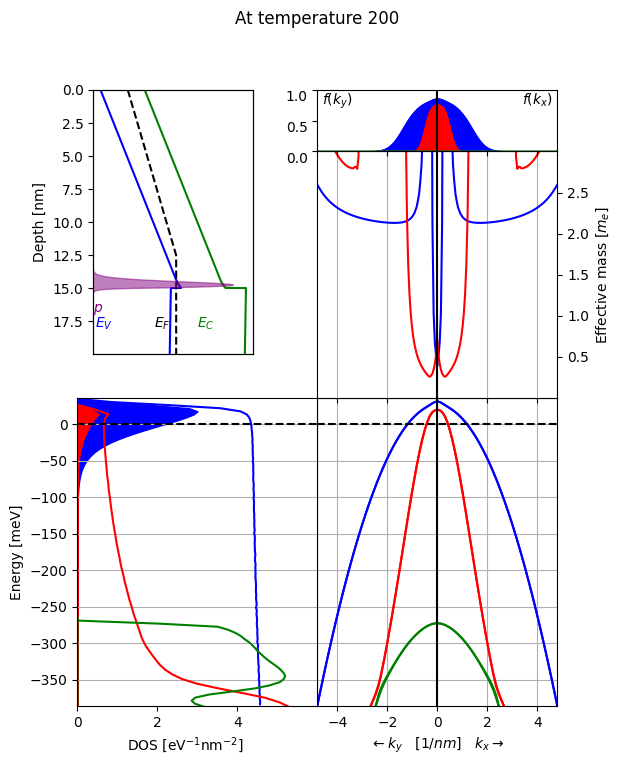

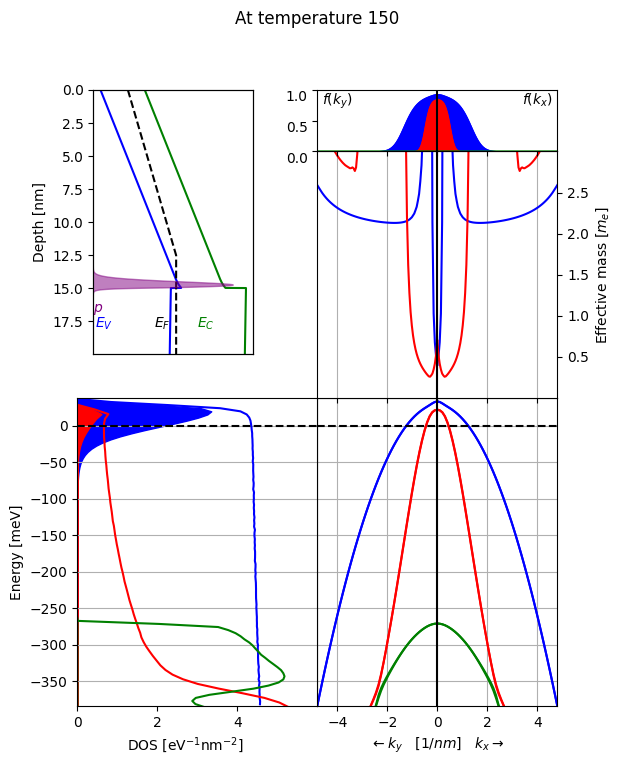

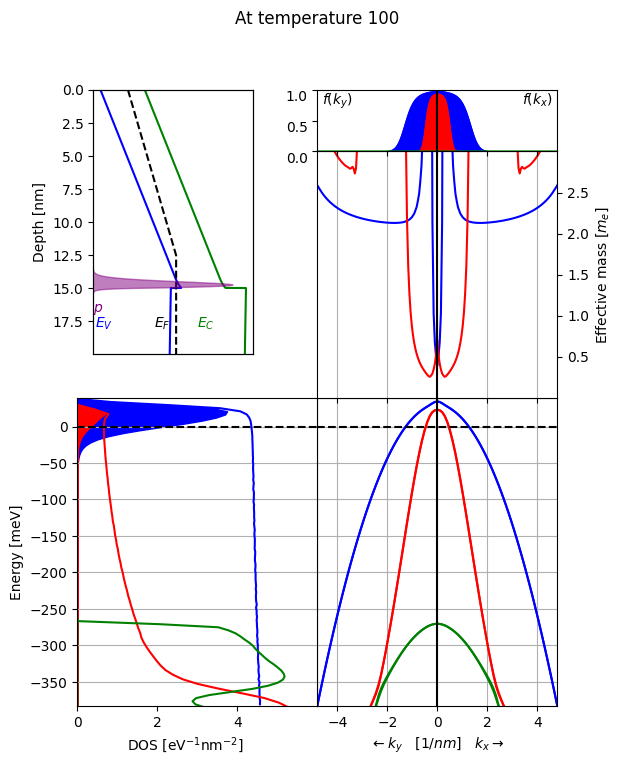

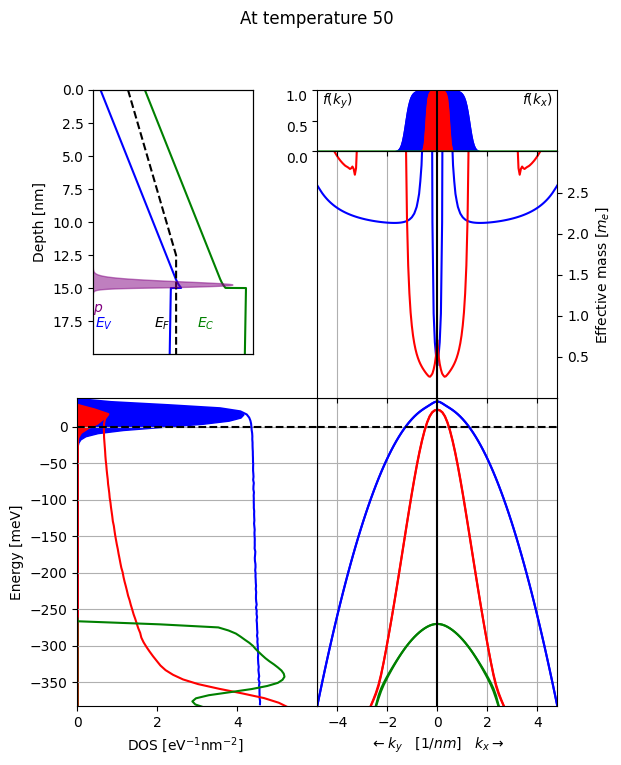

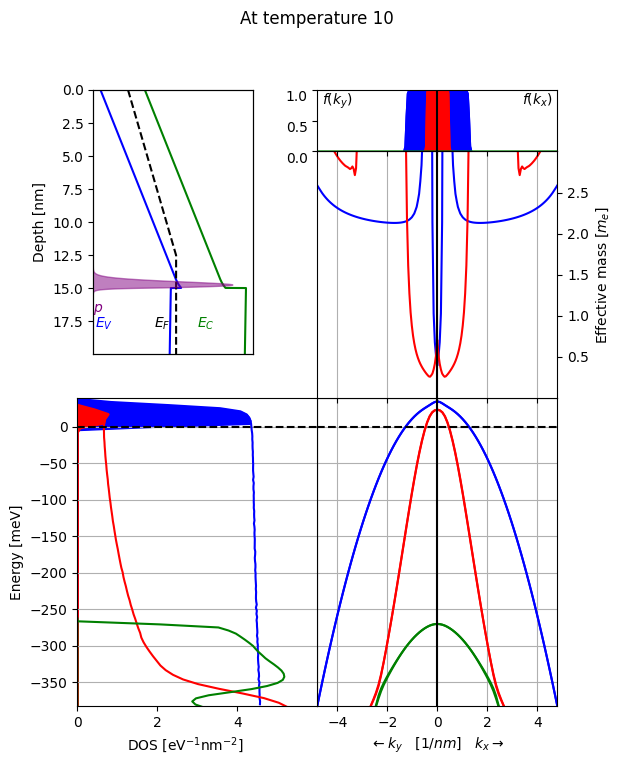

In [6]:
for T in t_points:
    sim=Simulation(f'pFET_nonInGaN_Tsweep_{int(T):g}',define_mesh=define_mesh,solve_flow=None)
    sim.load(force=False)

    m,quantum=sim.dmeshes['main'],sim.dmeshes['mbkp']
    rmesh=sim.rmeshes['mbkp_out']

    print(f"Temperature {T}K")
    print("Holes: {:.2f} x10^13/cm^2".format(to_unit(float(m.p.integrate(definite=True)),"1e13/cm^2")))
    print("EV-EF [meV]: {:.2f} meV".format(to_unit(float((m.Ev-m.EF.tmf())[m.indexm(sim.extras['well_t'])]),"meV")))
    
    from pynitride.physics.carriers import MultibandKP
    mbkp=MultibandKP(quantum,rmesh,num_eigenvalues=6)
    valence_band_panels(m,mbkp)
    plt.suptitle(f"At temperature {int(T):g}")

2023-12-10 21:36:35.470810     Mesh points 1053
2023-12-10 21:36:35.473811     Hoping to load previous run from pFET_yesInGaN_Tsweep_300*
2023-12-10 21:36:35.483344     Loaded
Temperature 300K
Holes: 4.69 x10^13/cm^2
EV-EF [meV]: -143.76 meV
2023-12-10 21:36:37.279553     Mesh points 1053
2023-12-10 21:36:37.281527     Hoping to load previous run from pFET_yesInGaN_Tsweep_200*
2023-12-10 21:36:37.290622     Loaded
Temperature 200K
Holes: 4.66 x10^13/cm^2
EV-EF [meV]: -148.48 meV
2023-12-10 21:36:39.022467     Mesh points 1053
2023-12-10 21:36:39.025947     Hoping to load previous run from pFET_yesInGaN_Tsweep_150*
2023-12-10 21:36:39.039978     Loaded
Temperature 150K
Holes: 4.65 x10^13/cm^2
EV-EF [meV]: -153.61 meV
2023-12-10 21:36:40.807450     Mesh points 1053
2023-12-10 21:36:40.811568     Hoping to load previous run from pFET_yesInGaN_Tsweep_100*
2023-12-10 21:36:40.824692     Loaded
Temperature 100K
Holes: 4.65 x10^13/cm^2
EV-EF [meV]: -159.56 meV
2023-12-10 21:36:42.687324     M

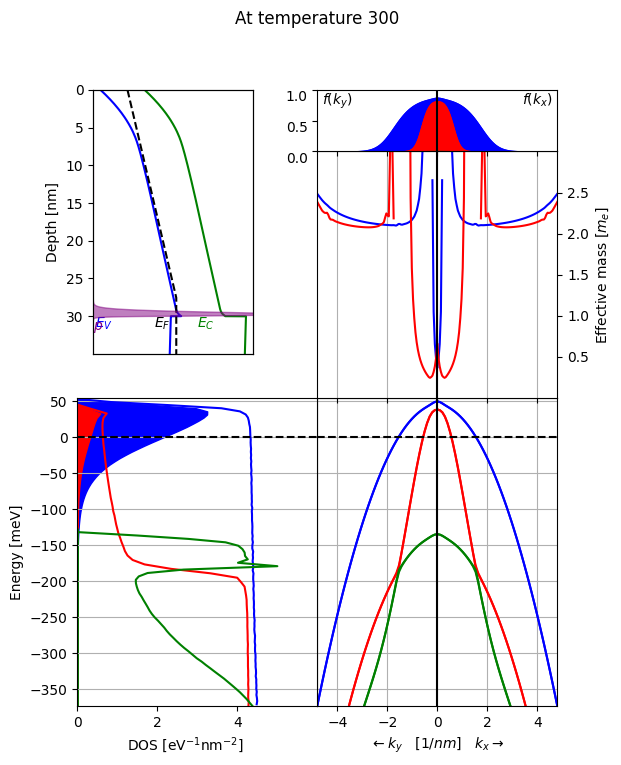

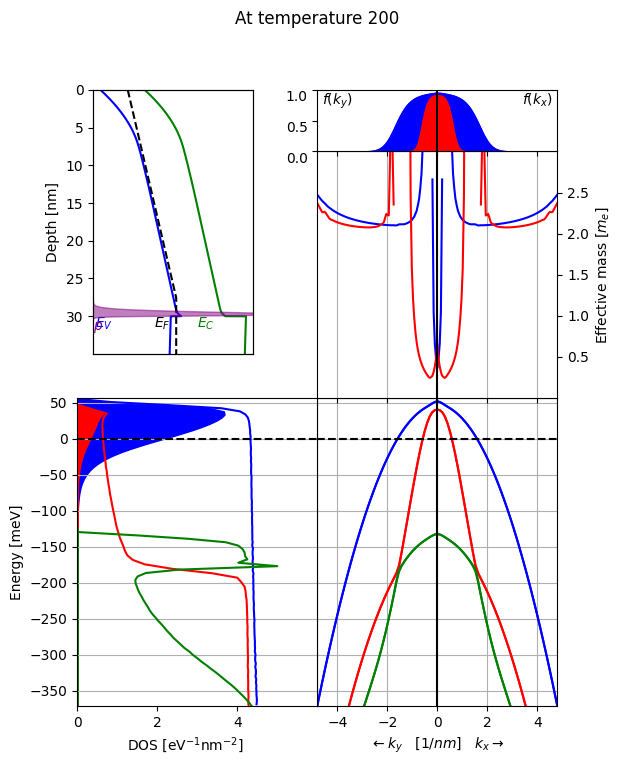

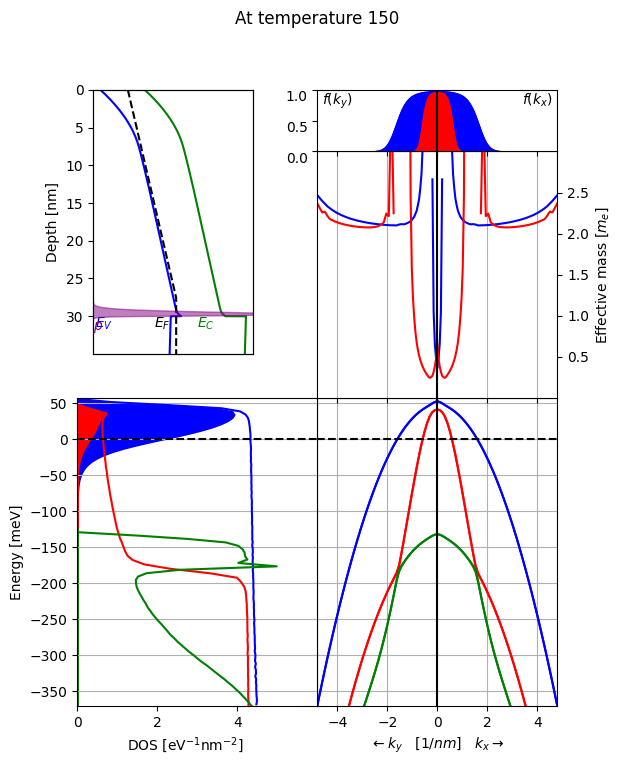

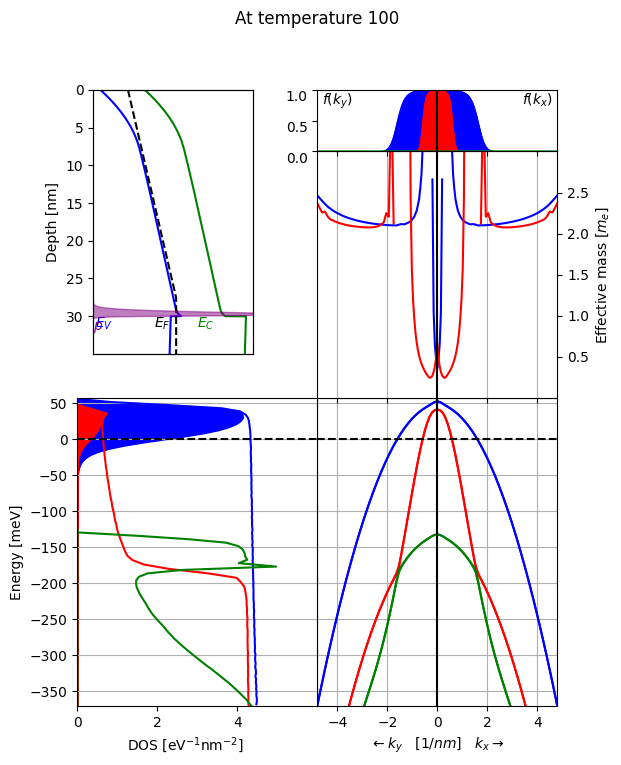

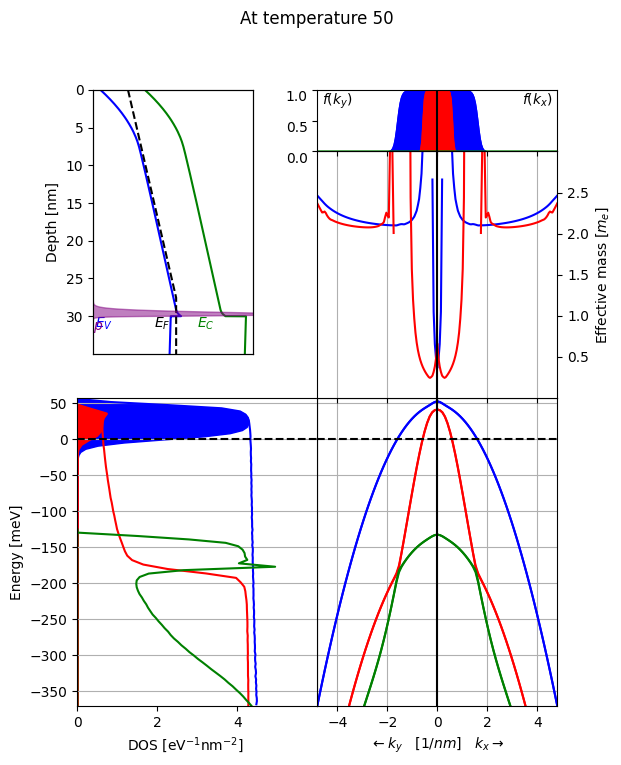

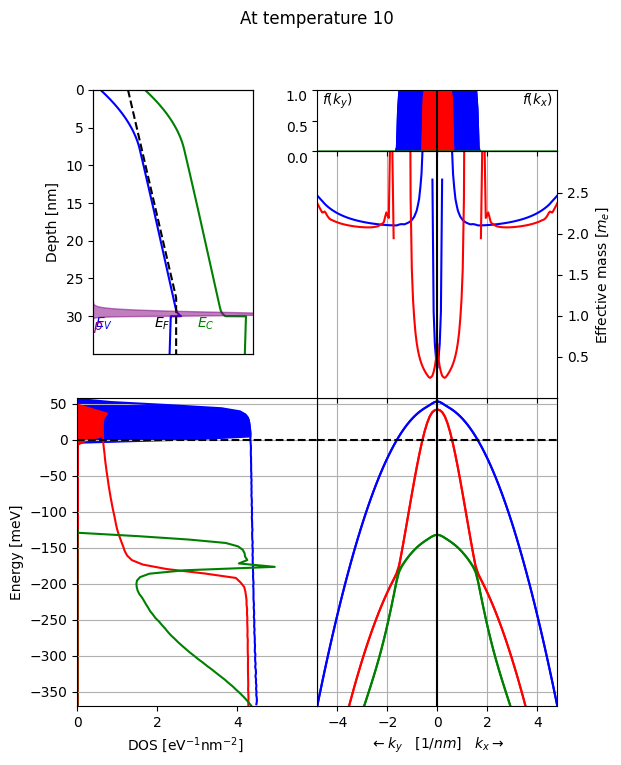

In [7]:
for T in t_points:
    sim=Simulation(f'pFET_yesInGaN_Tsweep_{int(T):g}',define_mesh=define_mesh,mesh_opts=mesh_opts_withcap,solve_flow=None)
    sim.load(force=False)

    m,quantum=sim.dmeshes['main'],sim.dmeshes['mbkp']
    rmesh=sim.rmeshes['mbkp_out']

    print(f"Temperature {T}K")
    print("Holes: {:.2f} x10^13/cm^2".format(to_unit(float(m.p.integrate(definite=True)),"1e13/cm^2")))
    print("EV-EF [meV]: {:.2f} meV".format(to_unit(float((m.Ev-m.EF.tmf())[m.indexm(sim.extras['well_t'])]),"meV")))
    
    from pynitride.physics.carriers import MultibandKP
    mbkp=MultibandKP(quantum,rmesh,num_eigenvalues=6)
    valence_band_panels(m,mbkp)
    plt.suptitle(f"At temperature {int(T):g}")